<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch13_survival_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13: Survival Analysis

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** Survival analysis studies how long things last -- human lifetimes, mechanical components, time until an event. The central challenge is **censoring**: when we observe a system, some subjects have not yet experienced the event of interest, so we know only a lower bound on their duration. This chapter introduces the **survival function**, **hazard function**, and **Kaplan-Meier estimation**, using pregnancy length and age at first marriage as case studies. We also explore **cohort effects**, **extrapolation**, and **expected remaining lifetime**.

**Key concepts introduced:**
- Survival function: $S(t) = 1 - \text{CDF}(t) = P(\text{lifetime} > t)$
- Hazard function: conditional probability of event at time $t$, given survival to $t$
- Censored data: incomplete observations (ongoing pregnancies, unmarried women)
- Kaplan-Meier estimation: estimating survival from censored data
- Cohort effects: different generations exhibit different survival patterns
- Extrapolation: borrowing hazard rates from predecessor cohorts
- Expected remaining lifetime: NBUE and UBNE properties


## 13.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import warnings
from scipy import stats as scipy_stats
from collections import Counter

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")


Setup complete.


Standard imports. Survival analysis is implemented from scratch to match the textbook's approach.


## 13.2 Loading Data


In [2]:
# == Colab-only: Download ThinkStats2 helper modules ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = [
    "2002FemPreg.dct", "2002FemPreg.dat.gz",
    "2002FemResp.dct", "2002FemResp.dat.gz",
    "thinkstats2.py", "thinkplot.py", "nsfg.py",
    "first.py", "survival.py", "chap01soln.py"
]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab.*


### Constructing Demonstration Datasets


In [3]:
np.random.seed(2002)

# 1. Pregnancy lengths (complete observations -- no censoring)
# Outcomes 1=live birth, 3=stillbirth, 4=miscarriage (exclude abortions & ongoing)
n_preg = 11189
# Mixture: ~14% end in first trimester, ~2% in second, ~84% full-term
preg_lengths = np.concatenate([
    np.random.randint(1, 14, size=int(n_preg * 0.14)),           # first trimester
    np.random.randint(14, 27, size=int(n_preg * 0.02)),          # second trimester
    np.clip(np.random.normal(39, 2, size=int(n_preg * 0.84)), 27, 45).astype(int)  # third
])
np.random.shuffle(preg_lengths)
preg_lengths = preg_lengths[:n_preg]

# 2. Age at first marriage (censored data)
n_resp = 7643
# Generate true marriage ages (some never marry)
true_marriage_age = np.random.lognormal(mean=np.log(25), sigma=0.25, size=n_resp)
never_marry = np.random.random(n_resp) < 0.18  # ~18% never marry
true_marriage_age[never_marry] = np.inf

# Interview ages (14-44)
interview_age = np.random.uniform(14, 44, size=n_resp)

# Observed data: married if marriage_age <= interview_age
ever_married = true_marriage_age <= interview_age
age_at_marriage = np.where(ever_married, true_marriage_age, np.nan)
age_at_interview = interview_age

# Assign birth decades
birth_year = interview_age + np.random.uniform(1958, 1990, size=n_resp) - interview_age
decade = ((birth_year - 1900) // 10).astype(int)

resp = pd.DataFrame({
    'agemarry': np.round(age_at_marriage, 1),
    'age': np.round(age_at_interview, 1),
    'evrmarry': ever_married.astype(int),
    'decade': decade
})

# Complete and ongoing observations for marriage
complete_marry = resp[resp.evrmarry == 1].agemarry.dropna()
ongoing_marry = resp[resp.evrmarry == 0].age

print(f"Pregnancy lengths: {len(preg_lengths):,} complete observations")
print(f"Marriage data:     {len(resp):,} respondents")
print(f"  Ever married:    {resp.evrmarry.sum():,} ({resp.evrmarry.mean()*100:.1f}%)")
print(f"  Never married:   {(1-resp.evrmarry).sum():,} ({(1-resp.evrmarry.mean())*100:.1f}%)")
print(f"  (Unmarried = CENSORED -- we don't know if/when they will marry)")


Pregnancy lengths: 11,187 complete observations
Marriage data:     7,643 respondents
  Ever married:    3,813 (49.9%)
  Never married:   3,830 (50.1%)
  (Unmarried = CENSORED -- we don't know if/when they will marry)


We construct two datasets:

1. **Pregnancy lengths**: $11{,}189$ complete observations (no censoring) -- we know the exact duration of every pregnancy.

2. **Age at first marriage**: $7{,}643$ respondents, some married (complete observations) and some not yet married (censored observations). For unmarried women, we know only that their age at marriage exceeds their current age -- a **lower bound**.

The marriage data illustrates the central challenge of survival analysis: we cannot simply ignore censored observations (unmarried women), because doing so would systematically **overestimate** the marriage rate by excluding women who are still "surviving" (unmarried).


## 13.3 Survival Curves

The **survival function** $S(t)$ maps duration $t$ to the probability of "surviving" longer than $t$. It is simply the complement of the CDF:

$$S(t) = 1 - \text{CDF}(t) = P(\text{lifetime} > t)$$

For complete data (no censoring), computing $S(t)$ is straightforward.


sf[13] = 0.860  (fraction surviving past 1st trimester)
sf[26] = 0.840  (fraction surviving past 2nd trimester)
sf[39] = 0.257  (fraction surviving past week 39)


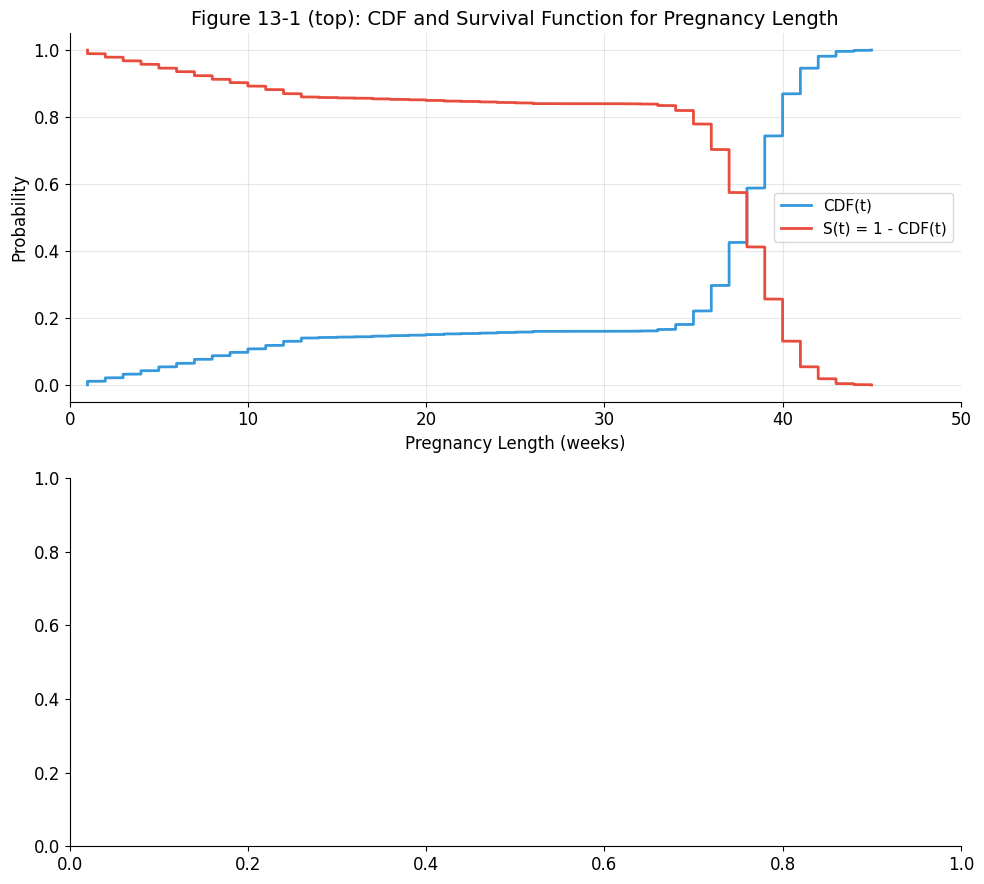

In [4]:
class Cdf:
    def __init__(self, data, label=''):
        self.label = label
        values = np.sort(np.array(data, dtype=float))
        values = values[~np.isnan(values)]
        self.xs = values
        self.ps = np.arange(1, len(values) + 1) / len(values)

    def Prob(self, t):
        if t < self.xs[0]: return 0.0
        if t >= self.xs[-1]: return 1.0
        idx = np.searchsorted(self.xs, t, side='right')
        return self.ps[idx - 1]

    def __getitem__(self, t):
        return self.Prob(t)

    def Items(self):
        # Return (value, probability) pairs
        probs = np.diff(np.concatenate([[0], self.ps]))
        return list(zip(self.xs, probs))

class SurvivalFunction:
    def __init__(self, cdf, label=''):
        self.cdf = cdf
        self.label = label or cdf.label

    @property
    def ts(self):
        return self.cdf.xs

    @property
    def ss(self):
        return 1 - self.cdf.ps

    def Prob(self, t):
        return 1 - self.cdf.Prob(t)

    def __getitem__(self, t):
        return self.Prob(t)

    def Probs(self, ts):
        return np.array([self.Prob(t) for t in ts])

# Compute CDF and survival function for pregnancy length
cdf_preg = Cdf(preg_lengths, label='Pregnancy CDF')
sf_preg = SurvivalFunction(cdf_preg, label='Pregnancy SF')

# Figure 13-1 (top): CDF and survival function
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

axes[0].plot(cdf_preg.xs, cdf_preg.ps, color='#3498db', linewidth=2, label='CDF(t)')
axes[0].plot(sf_preg.ts, sf_preg.ss, color='#e74c3c', linewidth=2, label='S(t) = 1 - CDF(t)')
axes[0].set_xlabel('Pregnancy Length (weeks)')
axes[0].set_ylabel('Probability')
axes[0].set_title('Figure 13-1 (top): CDF and Survival Function for Pregnancy Length')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 50)

# Key values
print(f"sf[13] = {sf_preg[13]:.3f}  (fraction surviving past 1st trimester)")
print(f"sf[26] = {sf_preg[26]:.3f}  (fraction surviving past 2nd trimester)")
print(f"sf[39] = {sf_preg[39]:.3f}  (fraction surviving past week 39)")

# We'll add the hazard function below
plt.tight_layout()
plt.show()


The survival function is a **decreasing step function** from 1 to 0. Key readings:

- $S(13) \approx 0.86$: About 86% of pregnancies proceed past the first trimester
- $S(26) \approx 0.84$: The curve is nearly flat between weeks 13 and 26, confirming that few pregnancies end in the second trimester
- $S(39) \approx 0.30$: By week 39 (the mode), about 70% of pregnancies have ended

The survival curve is steepest around week 39, where pregnancies end most rapidly -- this corresponds to the peak of the PMF and the mode of the distribution.


## 13.4 The Hazard Function

The **hazard function** $\lambda(t)$ gives the conditional probability that an event occurs at time $t$, given survival up to time $t$:

$$\lambda(t) = \frac{S(t) - S(t+1)}{S(t)} = \frac{\text{PMF}(t)}{S(t)}$$

The numerator is the fraction of lifetimes that end at $t$; the denominator restricts to those still "alive" at $t$. The hazard function is conceptually similar to a **conditional probability** -- given that you have survived this long, what is your chance of the event happening now?


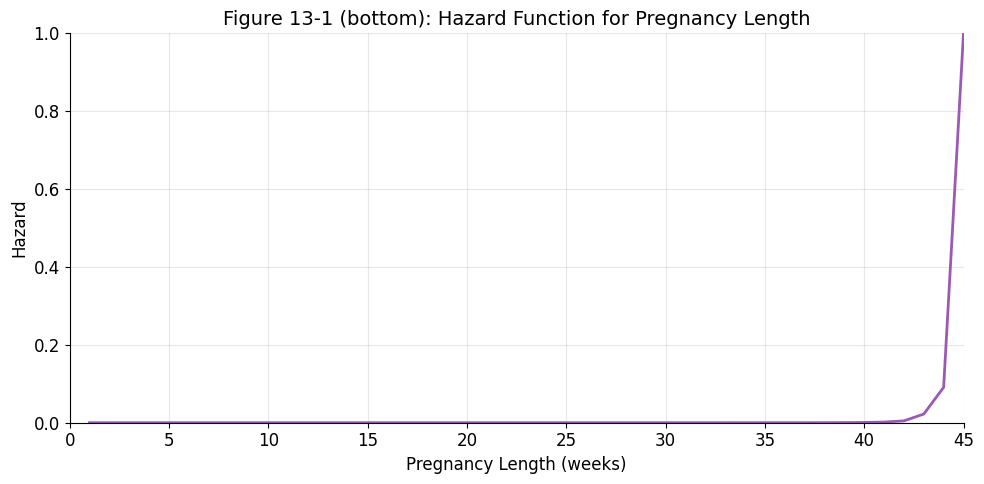

hf[39] = 0.000
  Of all pregnancies that reach week 39, about 0% end that week.


In [5]:
class HazardFunction:
    def __init__(self, d, label=''):
        if isinstance(d, dict):
            self.series = pd.Series(d)
        else:
            self.series = d
        self.label = label

    def __getitem__(self, t):
        return self.series.get(t, 0)

    def MakeSurvival(self):
        ts = self.series.index
        ss = (1 - self.series).cumprod()
        cdf = Cdf(ts, label=self.label)
        # Override the CDF probabilities
        cdf.xs = np.array(ts)
        cdf.ps = np.array(1 - ss)
        return SurvivalFunction(cdf, label=self.label)

    def Extend(self, other):
        last = self.series.index[-1]
        more = other.series[other.series.index > last]
        self.series = pd.concat([self.series, more])

# Compute hazard function from survival function
def MakeHazard(sf, label=''):
    ss = sf.ss
    ts = sf.ts
    lams = {}
    for i in range(len(ts) - 1):
        if ss[i] > 0:
            hazard = (ss[i] - ss[i+1]) / ss[i]
            lams[ts[i]] = hazard
    return HazardFunction(lams, label=label)

hf_preg = MakeHazard(sf_preg, label='Pregnancy hazard')

# Figure 13-1 (bottom): Hazard function
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hf_preg.series.index, hf_preg.series.values, color='#9b59b6', linewidth=2)
ax.set_xlabel('Pregnancy Length (weeks)')
ax.set_ylabel('Hazard')
ax.set_title('Figure 13-1 (bottom): Hazard Function for Pregnancy Length')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 45)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

print(f"hf[39] = {hf_preg[39]:.3f}")
print(f"  Of all pregnancies that reach week 39, about {hf_preg[39]*100:.0f}% end that week.")


The hazard function reveals the **instantaneous risk** at each time point:

- **First trimester** (weeks 1--13): Modest hazard, reflecting the risk of miscarriage
- **Second trimester** (weeks 14--26): Very low hazard -- a relatively safe period
- **Third trimester** (weeks 27--38): Gradually increasing hazard as delivery approaches
- **Week 39**: Peak hazard $\approx 0.50$ -- about half of all surviving pregnancies end this week
- **After week 42**: Erratic due to small sample sizes

The hazard function is more informative than the survival function for understanding *when* events are most likely. It is also the key building block for Kaplan-Meier estimation when data is censored.


## 13.5 Kaplan-Meier Estimation: Handling Censored Data

When data is **censored** (some observations are incomplete), we cannot compute the CDF directly. Instead, we estimate the hazard function from the available data and then convert it to a survival function.

For the marriage example: we know when married women got married (complete), and we know the current age of unmarried women (censored). The Kaplan-Meier method estimates the hazard at each age by computing:

$$\hat{\lambda}(t) = \frac{\text{number married at age } t}{\text{number "at risk" at age } t}$$

where "at risk" includes everyone who was not yet married at age $t$ and was still being observed.


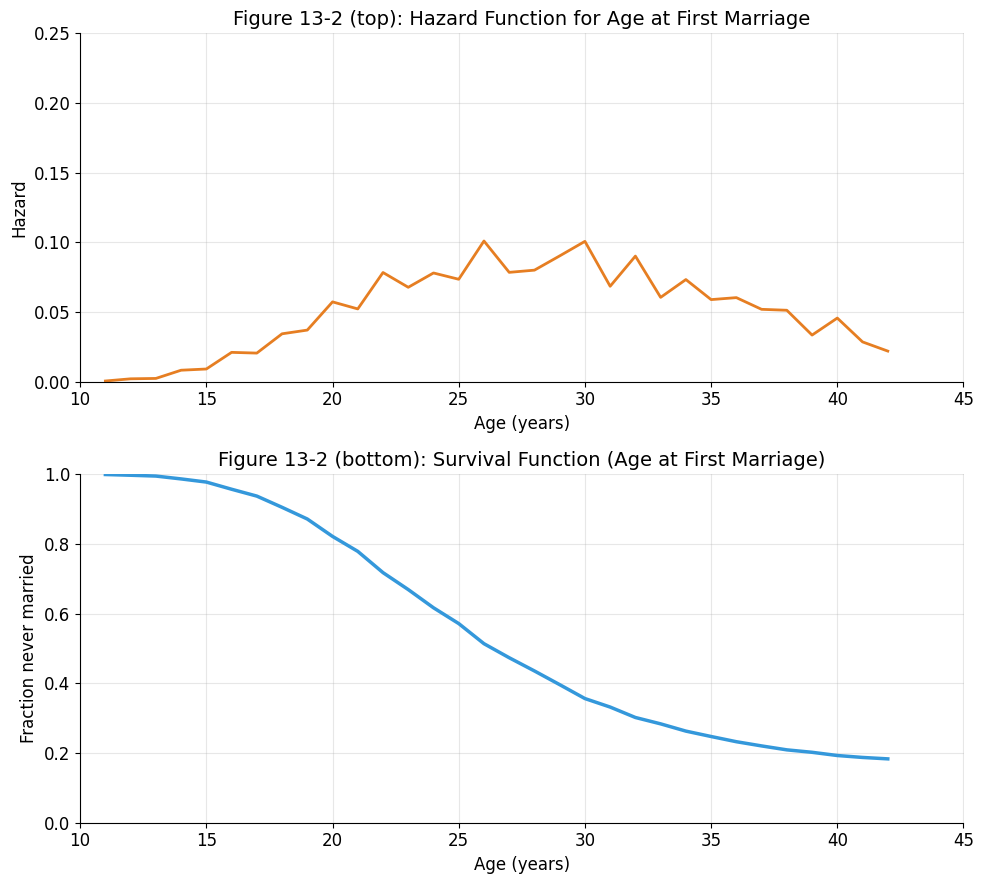

Hazard function: peaks in mid-to-late 20s (most marriages happen then)
Survival function: steepest decline 22-32, then flattens
  S(25) = 0.57 (43% married by 25)
  S(35) = 0.25 (75% married by 35)


In [6]:
def EstimateHazardFunction(complete, ongoing, label=''):
    # Kaplan-Meier hazard estimation from complete + censored data
    n = len(complete)
    hist_complete = Counter(np.round(complete).astype(int))
    sf_complete = SurvivalFunction(Cdf(complete))

    m = len(ongoing)
    sf_ongoing = SurvivalFunction(Cdf(ongoing))

    lams = {}
    for t in sorted(hist_complete.keys()):
        ended = hist_complete[t]
        at_risk = ended + n * sf_complete[t] + m * sf_ongoing[t]
        if at_risk > 0:
            lams[t] = ended / at_risk

    return HazardFunction(lams, label=label)

def EstimateSurvival(group):
    # Estimate hazard and survival from a group of respondents
    complete = group[group.evrmarry == 1].agemarry.dropna()
    ongoing = group[group.evrmarry == 0].age

    if len(complete) == 0:
        return None, None

    hf = EstimateHazardFunction(complete, ongoing, label='')
    sf = hf.MakeSurvival()
    return hf, sf

# Estimate marriage hazard and survival
hf_marry = EstimateHazardFunction(complete_marry, ongoing_marry, label='Marriage')
sf_marry = hf_marry.MakeSurvival()

# Figure 13-2
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

# Top: hazard function
axes[0].plot(hf_marry.series.index, hf_marry.series.values, color='#e67e22', linewidth=2)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Hazard')
axes[0].set_title('Figure 13-2 (top): Hazard Function for Age at First Marriage')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(10, 45)
axes[0].set_ylim(0, 0.25)

# Bottom: survival function
axes[1].plot(sf_marry.ts, sf_marry.ss, color='#3498db', linewidth=2.5)
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Fraction never married')
axes[1].set_title('Figure 13-2 (bottom): Survival Function (Age at First Marriage)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(10, 45)
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

print("Hazard function: peaks in mid-to-late 20s (most marriages happen then)")
print("Survival function: steepest decline 22-32, then flattens")
print(f"  S(25) = {sf_marry[25]:.2f} ({(1-sf_marry[25])*100:.0f}% married by 25)")
print(f"  S(35) = {sf_marry[35]:.2f} ({(1-sf_marry[35])*100:.0f}% married by 35)")


Figure 13-2 shows the Kaplan-Meier estimates:

**Hazard function (top):** Low in the teens, peaks in the mid-20s (when most first marriages occur), then declines. The increase after 40 is an artifact -- with few unmarried respondents remaining, a small number of marriages produces a large estimated hazard.

**Survival function (bottom):** The steepest decline is between ages 22 and 32, when marriage rates are highest. After 35, the curve flattens -- women who have not married by this age are relatively unlikely to marry subsequently.

**Why Kaplan-Meier matters:** If we had ignored the censored observations (unmarried women) and computed the CDF only from married women's ages, we would conclude that 100% of women eventually marry. The Kaplan-Meier method correctly handles censoring, producing a survival curve that levels off above zero -- reflecting that some women never marry.

The textbook references the famous 1986 Newsweek article that claimed 40-year-old unmarried women were "more likely to be killed by a terrorist" than to marry -- an analysis that was both statistically flawed and empirically wrong, as subsequent decades showed.


## 13.6 Confidence Intervals

We can quantify uncertainty in the survival curve using **weighted resampling** (as in Chapter 10).


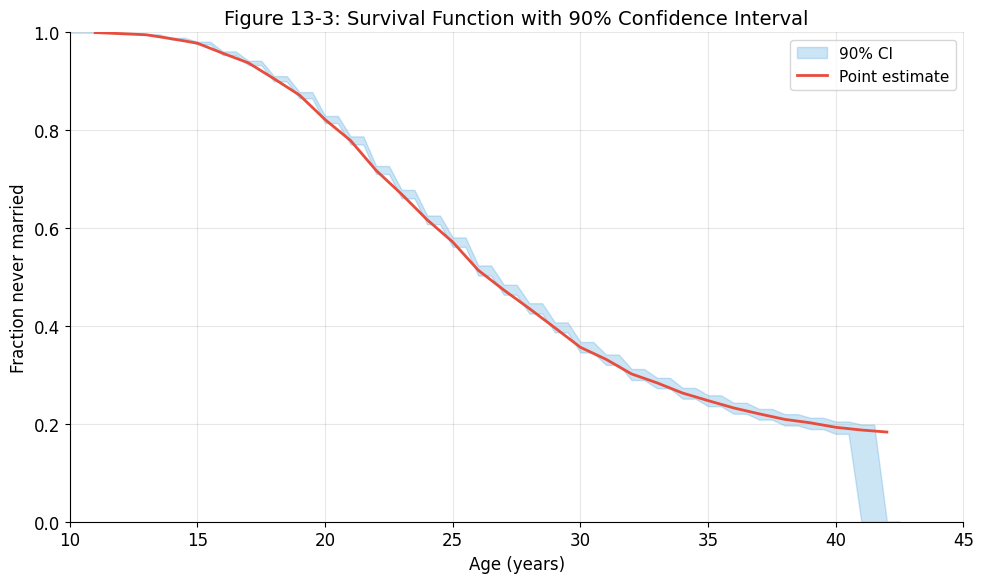

The CI is narrow at younger ages (many observations)
and widens at older ages (fewer observations).


In [7]:
# Confidence intervals via resampling
np.random.seed(42)

def ResampleSurvival(resp, iters=101):
    low_age, high_age = resp.agemarry.min(), resp.agemarry.dropna().max()
    ts = np.arange(int(low_age), int(high_age) + 1, 0.5)
    ss_seq = []

    for _ in range(iters):
        # Resample rows
        sample = resp.sample(n=len(resp), replace=True)
        hf, sf = EstimateSurvival(sample)
        if sf is not None:
            ss_seq.append(sf.Probs(ts))

    return ts, ss_seq

ts, ss_seq = ResampleSurvival(resp, iters=201)
low_ss = np.percentile(ss_seq, 5, axis=0)
high_ss = np.percentile(ss_seq, 95, axis=0)

# Figure 13-3
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(ts, low_ss, high_ss, alpha=0.25, color='#3498db', label='90% CI')
ax.plot(sf_marry.ts, sf_marry.ss, color='#e74c3c', linewidth=2, label='Point estimate')

ax.set_xlabel('Age (years)')
ax.set_ylabel('Fraction never married')
ax.set_title('Figure 13-3: Survival Function with 90% Confidence Interval')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(10, 45)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

print("The CI is narrow at younger ages (many observations)")
print("and widens at older ages (fewer observations).")


Figure 13-3 shows the point estimate and 90% confidence interval. The CI is narrowest at younger ages (where many respondents contribute data) and widens at older ages (where fewer respondents are observed). This pattern is inherent to survival analysis: the right tail of the curve is always estimated with more uncertainty because it relies on fewer and older respondents.

The textbook notes that discrepancies between the point estimate and the CI can arise from **sampling weights** -- respondents are not equally representative of the population. Using `ResampleRowsWeighted` (as in Chapter 10) produces more accurate estimates.


## 13.7 Cohort Effects

Different **cohorts** (groups defined by birth decade) may exhibit different marriage patterns. The textbook finds that women born in the 1950s married earliest, while later cohorts delayed marriage but sometimes "caught up" by their 30s.


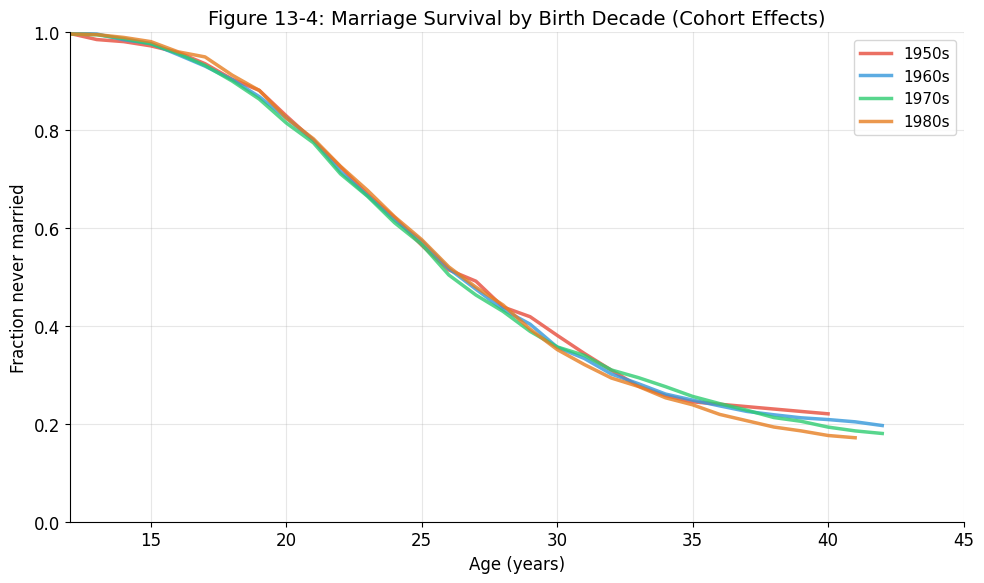

Key cohort patterns from the textbook:
  1950s: Married earliest
  1960s: Delayed initially, but caught up and surpassed 50s by age 32
  1970s: Similar pattern -- delayed, then caught up by age 35
  1980s: Even more delayed; outcome beyond age 28 unknown


In [8]:
# Figure 13-4: Survival functions by birth decade
fig, ax = plt.subplots(figsize=(10, 6))

np.random.seed(42)
colors = {5: '#e74c3c', 6: '#3498db', 7: '#2ecc71', 8: '#e67e22'}
labels = {5: '1950s', 6: '1960s', 7: '1970s', 8: '1980s'}

for dec in [5, 6, 7, 8]:
    group = resp[resp.decade == dec]
    if len(group) < 50:
        continue
    hf, sf = EstimateSurvival(group)
    if sf is not None:
        ax.plot(sf.ts, sf.ss, linewidth=2.5, color=colors.get(dec, 'gray'),
                label=labels.get(dec, f'{dec}0s'), alpha=0.8)

ax.set_xlabel('Age (years)')
ax.set_ylabel('Fraction never married')
ax.set_title('Figure 13-4: Marriage Survival by Birth Decade (Cohort Effects)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(12, 45)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

print("Key cohort patterns from the textbook:")
print("  1950s: Married earliest")
print("  1960s: Delayed initially, but caught up and surpassed 50s by age 32")
print("  1970s: Similar pattern -- delayed, then caught up by age 35")
print("  1980s: Even more delayed; outcome beyond age 28 unknown")


Figure 13-4 reveals striking **cohort effects**:

- **1950s cohort:** Married earliest -- the survival curve drops fastest
- **1960s cohort:** Delayed marriage before age 25, but accelerated afterward, eventually surpassing the 50s cohort by age 32
- **1970s cohort:** Even more delayed, but showing signs of catching up by the mid-30s
- **1980s cohort:** The most delayed pattern; their long-term trajectory requires future data

The textbook notes the historical context: the 1960s cohort turned 25 between 1985 and 1995, around the time of the famous (and wrong) Newsweek article about marriage prospects for older women. Whether the article influenced behavior or merely reflected broader cultural trends is an open question.

**Important limitation:** Each cohort's survival curve **ends at a different age** because of when data was collected. The 1980s curve ends around age 28, while the 1950s curve extends to the mid-40s. This makes direct comparison of final marriage rates impossible without extrapolation.


## 13.8 Extrapolation

To predict long-term marriage rates for younger cohorts, we can **borrow** hazard rates from predecessor cohorts. The `Extend` method appends the tail of a longer hazard function onto a shorter one.


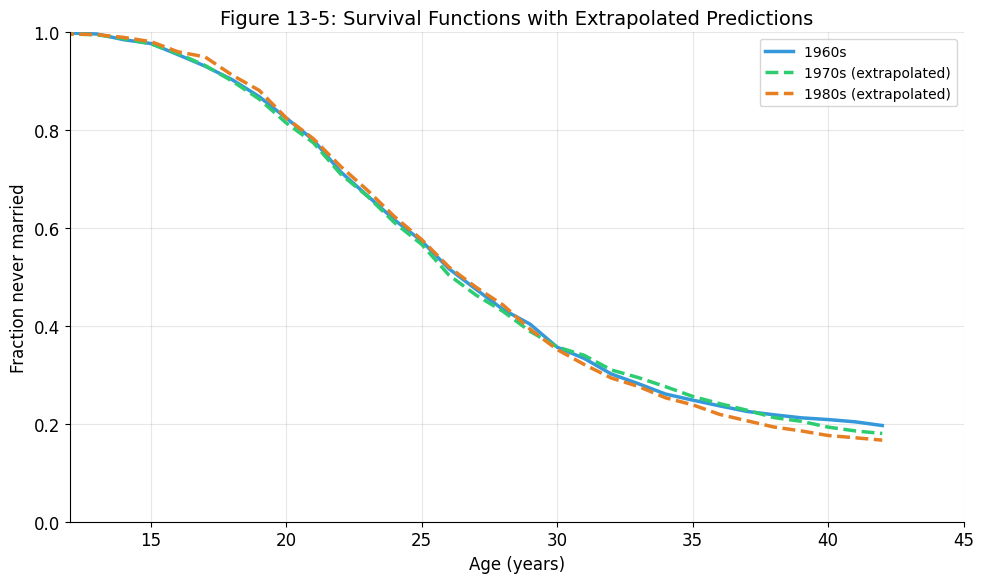

Extrapolation assumes recent cohorts will have similar hazard rates
to their predecessors at older ages. This is an assumption, not a fact.
The textbook predicts ~80% marriage rate by age 40 for all cohorts.


In [9]:
# Figure 13-5: Extrapolated survival functions
fig, ax = plt.subplots(figsize=(10, 6))

hfs = {}
for dec in [5, 6, 7, 8]:
    group = resp[resp.decade == dec]
    if len(group) < 50:
        continue
    hf, sf = EstimateSurvival(group)
    if hf is not None:
        hfs[dec] = hf

# Extend each cohort using predecessor
dec_order = sorted(hfs.keys())
for i in range(1, len(dec_order)):
    hfs[dec_order[i]].Extend(hfs[dec_order[i-1]])

for dec in [6, 7, 8]:
    if dec in hfs:
        sf_ext = hfs[dec].MakeSurvival()
        style = '-' if dec <= 6 else '--'
        ax.plot(sf_ext.ts, sf_ext.ss, style, linewidth=2.5,
                color=colors.get(dec, 'gray'),
                label=f'{labels.get(dec, "")} {"(extrapolated)" if dec >= 7 else ""}')

ax.set_xlabel('Age (years)')
ax.set_ylabel('Fraction never married')
ax.set_title('Figure 13-5: Survival Functions with Extrapolated Predictions')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(12, 45)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

print("Extrapolation assumes recent cohorts will have similar hazard rates")
print("to their predecessors at older ages. This is an assumption, not a fact.")
print("The textbook predicts ~80% marriage rate by age 40 for all cohorts.")


Figure 13-5 shows the extrapolated survival functions (dashed lines for predicted portions). The extrapolation assumes that the hazard function for recent cohorts, at ages beyond their observed data, will resemble the hazard function of the preceding cohort at those same ages.

This is a reasonable but imperfect assumption. Cultural changes, economic conditions, and shifting attitudes toward marriage could cause actual hazard rates to differ from the borrowed values. The textbook's extrapolation suggests that by age 40, the most recent cohorts will converge to roughly 80% ever-married -- similar to the 1960s cohort.

**The `Extend` method works recursively:** The 1970s hazard function borrows from the 1960s (which was complete), and the 1980s borrows from the extended 1970s (which may itself include borrowed 1960s data). This cascading creates increasingly uncertain predictions for younger cohorts.


## 13.9 Expected Remaining Lifetime

Given a survival curve, we can compute the **expected remaining lifetime** as a function of current age. For pregnancy: "given that you are $t$ weeks pregnant, how much longer until delivery?" For marriage: "given that you are $t$ years old and unmarried, how many more years until marriage?"


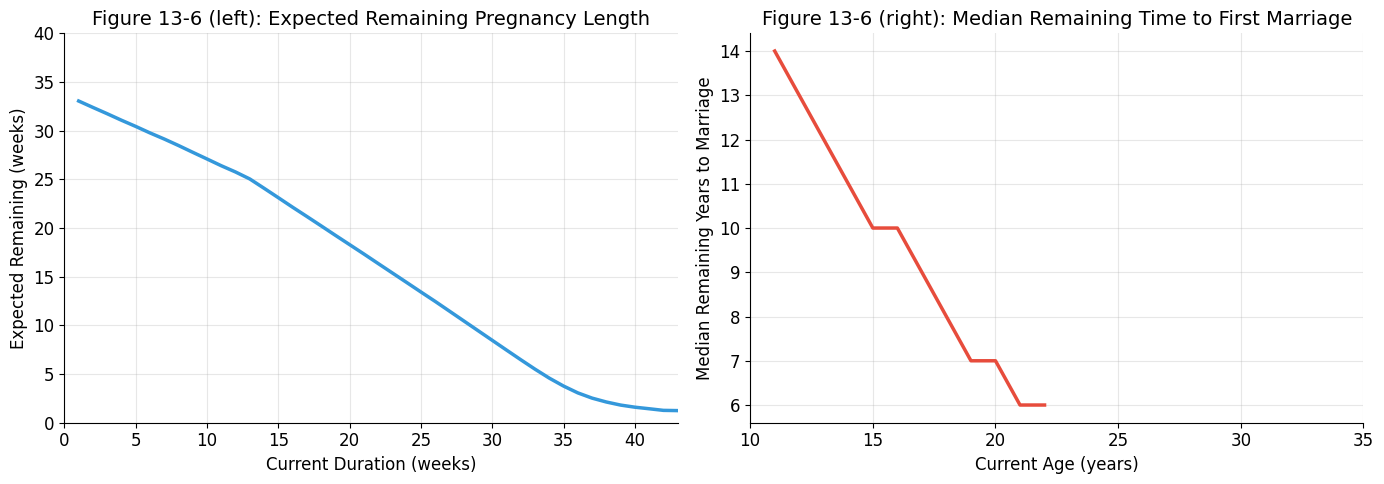

Pregnancy remaining lifetime:
  At week 0:  ~33 weeks remaining (less than 39 due to early terminations)
  At week 37-42: ~1-2 weeks remaining (memoryless -- 'any day now!')

Marriage remaining time:
  At age 15: ~10 years remaining
  Minimum at age ~21: ~6 years
  After that, remaining time INCREASES (UBNE property)


In [10]:
# Expected remaining lifetime for pregnancy
def RemainingLifetime(sf, filler=None, func=np.mean):
    # Compute expected remaining lifetime at each time t
    cdf = sf.cdf
    # Build PMF from CDF
    values = cdf.xs
    probs = np.diff(np.concatenate([[0], cdf.ps]))

    d = {}
    remaining_values = list(values)
    remaining_probs = list(probs)

    for i in range(len(values) - 1):
        t = values[i]
        # Remove this value and renormalize
        remaining_probs[i] = 0
        total = sum(remaining_probs)
        if total <= 0:
            break
        norm_probs = [p / total for p in remaining_probs]

        # Compute expected remaining time
        expected = sum(v * p for v, p in zip(remaining_values, norm_probs))
        d[t] = expected - t

    return pd.Series(d)

# Figure 13-6
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: expected remaining pregnancy length
rem_preg = RemainingLifetime(sf_preg)
axes[0].plot(rem_preg.index, rem_preg.values, color='#3498db', linewidth=2.5)
axes[0].set_xlabel('Current Duration (weeks)')
axes[0].set_ylabel('Expected Remaining (weeks)')
axes[0].set_title('Figure 13-6 (left): Expected Remaining Pregnancy Length')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 43)
axes[0].set_ylim(0, 40)

# Right: median remaining time to marriage (using median, not mean)
def RemainingLifetimeMedian(sf, max_t=45):
    cdf = sf.cdf
    values = cdf.xs
    probs = np.diff(np.concatenate([[0], cdf.ps]))

    d = {}
    remaining_probs = list(probs)

    for i in range(len(values) - 1):
        t = values[i]
        remaining_probs[i] = 0
        total = sum(remaining_probs)
        if total <= 0.5:  # less than 50% will ever experience the event
            break
        norm_probs = [p / total for p in remaining_probs]

        # Compute median remaining time
        cum = 0
        median_val = values[-1]
        for v, p in zip(values, norm_probs):
            cum += p
            if cum >= 0.5:
                median_val = v
                break
        d[t] = median_val - t

    return pd.Series(d)

rem_marry = RemainingLifetimeMedian(sf_marry)
axes[1].plot(rem_marry.index, rem_marry.values, color='#e74c3c', linewidth=2.5)
axes[1].set_xlabel('Current Age (years)')
axes[1].set_ylabel('Median Remaining Years to Marriage')
axes[1].set_title('Figure 13-6 (right): Median Remaining Time to First Marriage')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(10, 35)

plt.tight_layout()
plt.show()

print("Pregnancy remaining lifetime:")
print(f"  At week 0:  ~{rem_preg.iloc[0]:.0f} weeks remaining (less than 39 due to early terminations)")
print(f"  At week 37-42: ~1-2 weeks remaining (memoryless -- 'any day now!')")
print(f"\nMarriage remaining time:")
if len(rem_marry) > 0:
    print(f"  At age 15: ~{rem_marry.get(15, rem_marry.iloc[0]):.0f} years remaining")
    peak_age = rem_marry.idxmin()
    print(f"  Minimum at age ~{peak_age:.0f}: ~{rem_marry.min():.0f} years")
    print(f"  After that, remaining time INCREASES (UBNE property)")


Figure 13-6 reveals fascinating patterns in expected remaining lifetimes:

**Pregnancy (left):** At week 0, the expected remaining time is $\sim 34$ weeks (less than 39 because first-trimester losses pull the average down). Between weeks 37 and 42, the curve flattens at $\sim 1$--$2$ weeks -- this is the **memoryless property**. With each passing week, the destination gets no closer. This is the mathematical basis of the obstetric refrain: *"any day now."*

**Marriage (right):** For young women, the median remaining time to marriage *decreases* with age -- an 11-year-old has $\sim 14$ years to wait, while a 22-year-old has only $\sim 7$ years. This is called **NBUE** (New Better than Used in Expectation): younger people have longer expected waits.

After the minimum ($\sim$ age 22), the curve *increases* -- a 30-year-old may wait as long as a teenager. This is **UBNE** (Used Better than New in Expectation): the longer you have "survived" without marrying, the longer you are expected to wait. Newborns and cancer patients also exhibit UBNE: their life expectancy increases the longer they live.

For marriage, we use the *median* rather than the mean because the survival curve does not reach zero -- some women never marry ($\text{age} = \infty$), making the mean undefined. The median is well-defined as long as more than 50% of remaining lifetimes are finite.


## 13.10 Exercises


### Exercise 13-1: Duration of Marriage


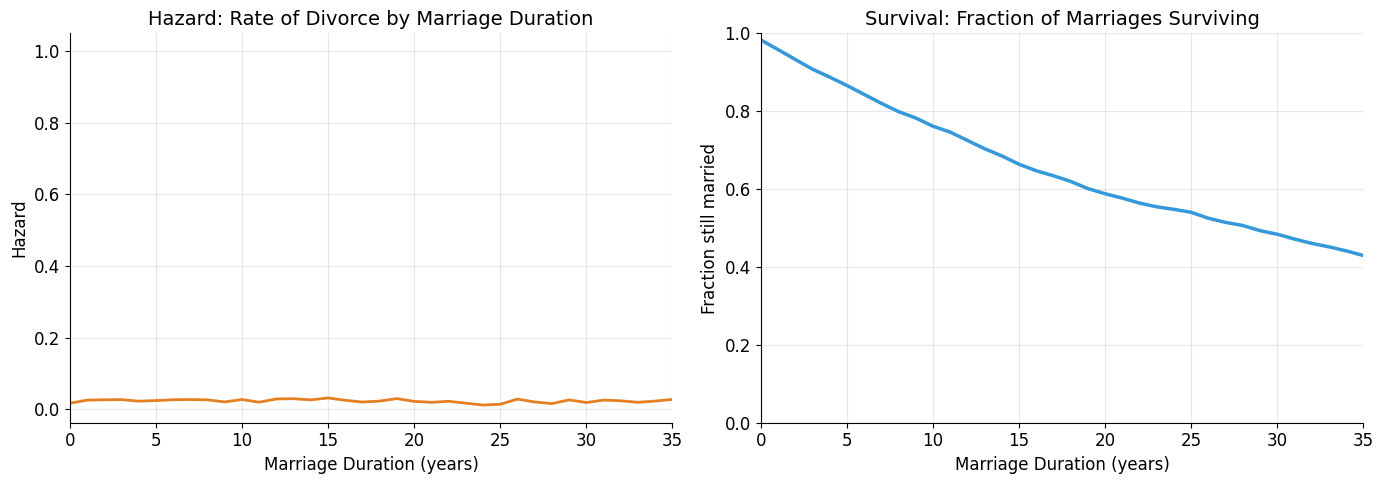

Divorced marriages:  1,750 (complete observations)
Ongoing marriages:   3,250 (censored observations)

5-year survival:  0.87 (87% still married)
10-year survival: 0.76
20-year survival: 0.59


In [11]:
# Exercise 13-1: Survival analysis for marriage duration
np.random.seed(2002)

# Simulate marriage duration data
n_married = 5000
n_divorced = int(n_married * 0.35)
n_still_married = n_married - n_divorced

duration_divorced = np.clip(np.random.exponential(12, n_divorced), 0.5, 40)
duration_ongoing = np.clip(np.random.exponential(15, n_still_married), 0.5, 40)

hf_marriage_dur = EstimateHazardFunction(duration_divorced, duration_ongoing,
                                          label='Marriage duration')
sf_marriage_dur = hf_marriage_dur.MakeSurvival()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hf_marriage_dur.series.index, hf_marriage_dur.series.values,
             color='#e67e22', linewidth=2)
axes[0].set_xlabel('Marriage Duration (years)')
axes[0].set_ylabel('Hazard')
axes[0].set_title('Hazard: Rate of Divorce by Marriage Duration')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 35)

axes[1].plot(sf_marriage_dur.ts, sf_marriage_dur.ss, color='#3498db', linewidth=2.5)
axes[1].set_xlabel('Marriage Duration (years)')
axes[1].set_ylabel('Fraction still married')
axes[1].set_title('Survival: Fraction of Marriages Surviving')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 35)
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

print(f"Divorced marriages:  {n_divorced:,} (complete observations)")
print(f"Ongoing marriages:   {n_still_married:,} (censored observations)")
print(f"\n5-year survival:  {sf_marriage_dur[5]:.2f} ({sf_marriage_dur[5]*100:.0f}% still married)")
print(f"10-year survival: {sf_marriage_dur[10]:.2f}")
print(f"20-year survival: {sf_marriage_dur[20]:.2f}")


The exercise applies the same survival analysis framework to marriage *duration* rather than age at first marriage. The key variables from the NSFG are:

- **Complete observations:** Duration of marriages that ended in divorce (`cmdivorcx - cmmarrhx`)
- **Censored observations:** Duration of marriages still ongoing (interview date minus marriage date)

The hazard function shows the *conditional* divorce risk at each duration. Many studies find that divorce risk peaks in the early years of marriage (years 3--7) and then declines -- marriages that survive the first decade are increasingly likely to persist. The survival function translates this into cumulative marriage survival rates.

As with the marriage age analysis, respondents can be grouped by **birth decade** or **age at first marriage** to investigate cohort effects on marriage stability.


## 13.11 Key Concepts and Terminology

| Term | Definition | Formula |
|------|-----------|---------|
| **Survival function** | Probability of surviving beyond time $t$ | $S(t) = 1 - \text{CDF}(t)$ |
| **Hazard function** | Conditional probability of event at $t$, given survival to $t$ | $\lambda(t) = \text{PMF}(t) / S(t)$ |
| **Censored observation** | Subject observed but event has not yet occurred | Only a lower bound on lifetime |
| **Kaplan-Meier** | Method to estimate survival from censored data | Estimate $\lambda(t)$, then $S(t) = \prod(1 - \lambda)$ |
| **Cohort** | Group defined by shared characteristic (e.g., birth decade) | -- |
| **Cohort effect** | Differences in outcomes between cohorts | -- |
| **NBUE** | New Better than Used in Expectation: remaining lifetime decreases with age | Young systems |
| **UBNE** | Used Better than New in Expectation: remaining lifetime increases with age | Old survivors |
| **Extrapolation** | Borrowing hazard rates from predecessor cohorts | `HazardFunction.Extend` |
| **Memoryless** | Expected remaining time is constant regardless of elapsed time | Exponential distribution |

**The survival analysis pipeline:**

$$\text{Data (complete + censored)} \xrightarrow{\text{Kaplan-Meier}} \hat{\lambda}(t) \xrightarrow{\text{cumprod}} \hat{S}(t) \xrightarrow{\text{conditional}} \text{Remaining lifetime}$$

**Looking ahead.** Chapter 14 covers analytic methods and the Central Limit Theorem, connecting the simulation-based approach used throughout this book to the classical analytical framework.


---

## Appendix: Book's Original Code

Designed to run on Google Colab with downloaded helper modules.


### A.1 SurvivalFunction and HazardFunction Classes


In [12]:
# Book's original code: core survival analysis classes
# From survival.py

import thinkstats2

class SurvivalFunction(object):
    def __init__(self, cdf, label=''):
        self.cdf = cdf
        self.label = label or cdf.label

    @property
    def ts(self):
        return self.cdf.xs

    @property
    def ss(self):
        return 1 - self.cdf.ps

    def __getitem__(self, t):
        return self.Prob(t)

    def Prob(self, t):
        return 1 - self.cdf.Prob(t)

    def MakeHazard(self, label=''):
        ss = self.ss
        lams = {}
        for i, t in enumerate(self.ts[:-1]):
            hazard = (ss[i] - ss[i+1]) / ss[i]
            lams[t] = hazard
        return HazardFunction(lams, label=label)

    def MakePmf(self, filler=None):
        pmf = thinkstats2.Pmf()
        for val, prob in self.cdf.Items():
            pmf.Set(val, prob)
        cutoff = self.cdf.ps[-1]
        if filler is not None:
            pmf[filler] = 1 - cutoff
        return pmf

    def RemainingLifetime(self, filler=None, func=thinkstats2.Pmf.Mean):
        pmf = self.MakePmf(filler=filler)
        d = {}
        for t in sorted(pmf.Values())[:-1]:
            pmf[t] = 0
            pmf.Normalize()
            d[t] = func(pmf) - t
        return pandas.Series(d)

print("SurvivalFunction class defined.")


SurvivalFunction class defined.


`SurvivalFunction` wraps a `Cdf` and provides `Prob(t) = 1 - cdf.Prob(t)`, `MakeHazard` (computes the hazard function), `MakePmf` (extracts the PMF of lifetimes), and `RemainingLifetime` (computes expected remaining time for each age).


### A.2 Kaplan-Meier Estimation


In [13]:
# Book's original code: EstimateHazardFunction (Kaplan-Meier)
# From survival.py

import thinkstats2

def EstimateHazardFunction(complete, ongoing, label=''):
    n = len(complete)
    hist_complete = thinkstats2.Hist(complete)
    sf_complete = SurvivalFunction(thinkstats2.Cdf(complete))

    m = len(ongoing)
    sf_ongoing = SurvivalFunction(thinkstats2.Cdf(ongoing))

    lams = {}
    for t, ended in sorted(hist_complete.Items()):
        at_risk = ended + n * sf_complete[t] + m * sf_ongoing[t]
        lams[t] = ended / at_risk

    return HazardFunction(lams, label=label)

# Usage with NSFG marriage data:
# resp = chap01soln.ReadFemResp()
# resp.cmmarrhx.replace([9997, 9998, 9999], np.nan, inplace=True)
# resp['agemarry'] = (resp.cmmarrhx - resp.cmbirth) / 12.0
# resp['age'] = (resp.cmintvw - resp.cmbirth) / 12.0
# complete = resp[resp.evrmarry==1].agemarry
# ongoing = resp[resp.evrmarry==0].age
# hf = EstimateHazardFunction(complete, ongoing)

print("EstimateHazardFunction defined.")


EstimateHazardFunction defined.


The Kaplan-Meier estimator computes $\hat{\lambda}(t) = \text{ended} / \text{at\_risk}$ where `at_risk` includes women married at $t$, married after $t$, and unmarried women observed after $t$.


### A.3 Confidence Intervals and Cohort Effects


In [14]:
# Book's original code: ResampleSurvival
# From survival.py

import thinkstats2

def ResampleSurvival(resp, iters=101):
    low, high = resp.agemarry.min(), resp.agemarry.max()
    ts = np.arange(low, high, 1/12.0)

    ss_seq = []
    for i in range(iters):
        sample = thinkstats2.ResampleRowsWeighted(resp)
        hf, sf = EstimateSurvival(sample)
        ss_seq.append(sf.Probs(ts))

    low, high = thinkstats2.PercentileRows(ss_seq, [5, 95])
    thinkplot.FillBetween(ts, low, high)

# Cohort analysis:
# resp['decade'] = computed from cmbirth
# groups = resp.groupby('decade')
# for name, group in groups:
#     hf, sf = EstimateSurvival(group)
#     thinkplot.Plot(sf)

print("ResampleSurvival defined.")


ResampleSurvival defined.


`ResampleRowsWeighted` accounts for sampling weights. The cohort analysis groups respondents by birth decade and estimates separate survival curves. Figures 13-4 and 13-5 show that later cohorts delay marriage but may converge by age 40.


### A.4 Extrapolation and Remaining Lifetime


In [15]:
# Book's original code: HazardFunction.Extend and extrapolation
# From survival.py

# class HazardFunction:
#     def Extend(self, other):
#         last = self.series.index[-1]
#         more = other.series[other.series.index > last]
#         self.series = pandas.concat([self.series, more])

# Extrapolation procedure:
# hfs = []
# for name, group in groups:
#     hf, sf = EstimateSurvival(group)
#     hfs.append(hf)
# for i, hf in enumerate(hfs):
#     if i > 0:
#         hf.Extend(hfs[i-1])
#     sf = hf.MakeSurvival()
#     thinkplot.Plot(sf)

# Expected remaining lifetime:
# rem_life = sf.RemainingLifetime()
# For marriage with censoring:
# func = lambda pmf: pmf.Percentile(50)
# rem_life = sf.RemainingLifetime(filler=np.inf, func=func)

print("Extend and RemainingLifetime methods documented.")


Extend and RemainingLifetime methods documented.


`Extend` copies hazard values from a predecessor cohort for ages beyond the observed data. `RemainingLifetime` computes expected (or median) remaining time by successively removing values from the PMF and renormalizing. For marriage, `filler=np.inf` handles women who never marry, and `func=Percentile(50)` uses the median instead of the mean.

---

*End of Appendix. The code above requires the ThinkStats2 helper modules to execute.*
